In [113]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


In [114]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = (PROJECT_ROOT / "data" / "raw").resolve()
print("RAW_DIR:", RAW_DIR)


def inspect_csv(name) -> pd.DataFrame:
    path = RAW_DIR / f"{name}.csv"
    print(f"=== {name} ===")
    print("Path:", path)

    df = pd.read_csv(path)
    print("Shape of the dataframe: ", df.shape)
    print("Columns: ", df.columns.tolist())
    print("Info", df.info())
    print("Missing values: ", df.isnull().sum())
    print("Duplicate values: ", df.duplicated().sum())
    display(df.head(5))
    return df


RAW_DIR: C:\Users\saksh\OneDrive - University of Keele\Documents\Netflix_subscription_project\data\raw


In [115]:
df_churn_labels = inspect_csv("churn_labels")

=== churn_labels ===
Path: C:\Users\saksh\OneDrive - University of Keele\Documents\Netflix_subscription_project\data\raw\churn_labels.csv
Shape of the dataframe:  (8000, 4)
Columns:  ['customer_id', 'churned', 'churn_date', 'churn_reason']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   customer_id   8000 non-null   object
 1   churned       8000 non-null   bool  
 2   churn_date    1991 non-null   object
 3   churn_reason  1991 non-null   object
dtypes: bool(1), object(3)
memory usage: 195.4+ KB
Info None
Missing values:  customer_id        0
churned            0
churn_date      6009
churn_reason    6009
dtype: int64
Duplicate values:  0


,customer_id,churned,churn_date,churn_reason
0,CUST000001,False,NaN,NaN
1,CUST000002,False,NaN,NaN
2,CUST000003,True,2026-04-20,Too expensive
3,CUST000004,False,NaN,NaN
4,CUST000005,False,NaN,NaN


**Note:** 8,000 rows is close to ~8,048 customers; `churn_date` and `churn_reason` are missing for non-churned rows (expected), and dates loaded as text rather than datetime.

In [116]:
df_content = inspect_csv("content")

=== content ===
Path: C:\Users\saksh\OneDrive - University of Keele\Documents\Netflix_subscription_project\data\raw\content.csv
Shape of the dataframe:  (500, 9)
Columns:  ['content_id', 'title', 'content_type', 'genre', 'release_year', 'duration_minutes', 'content_language', 'production_country', 'maturity_rating']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   content_id          500 non-null    object
 1   title               500 non-null    object
 2   content_type        500 non-null    object
 3   genre               500 non-null    object
 4   release_year        500 non-null    int64 
 5   duration_minutes    500 non-null    int64 
 6   content_language    500 non-null    object
 7   production_country  500 non-null    object
 8   maturity_rating     500 non-null    object
dtypes: int64(2), object(7)
memory usage: 35.3+ KB

,content_id,title,content_type,genre,release_year,duration_minutes,content_language,production_country,maturity_rating
0,CNT00001,Golden Horizon,TV Show,Horror,2021,51,English,India,TV-14
1,CNT00002,Restless Kingdom,TV Show,Comedy,2004,39,English,United States,TV-MA
2,CNT00003,Silent Symphony,Movie,Family,2016,117,English,India,NR
3,CNT00004,Silent Legacy,TV Show,Stand-Up Comedy,2004,72,Indonesian,India,PG-13
4,CNT00005,Golden Kingdom,Movie,Reality,2017,100,English,Philippines,G


**Note:** 500 titles with no missing values or duplicates — this table looks clean.

In [117]:
df_customer_feedback = inspect_csv("customer_feedback")

=== customer_feedback ===
Path: C:\Users\saksh\OneDrive - University of Keele\Documents\Netflix_subscription_project\data\raw\customer_feedback.csv
Shape of the dataframe:  (5046, 6)
Columns:  ['feedback_id', 'customer_id', 'feedback_date', 'rating', 'feedback_text', 'sentiment_label']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5046 entries, 0 to 5045
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   feedback_id      5046 non-null   object
 1   customer_id      5046 non-null   object
 2   feedback_date    5046 non-null   object
 3   rating           5046 non-null   int64 
 4   feedback_text    5046 non-null   object
 5   sentiment_label  5046 non-null   object
dtypes: int64(1), object(5)
memory usage: 236.7+ KB
Info None
Missing values:  feedback_id        0
customer_id        0
feedback_date      0
rating             0
feedback_text      0
sentiment_label    0
dtype: int64
Duplicate values:  0


,feedback_id,customer_id,feedback_date,rating,feedback_text,sentiment_label
0,FB0000001,CUST000001,2025-12-25,1,"Not enough new content being added, feels like...",Negative
1,FB0000002,CUST000001,2022-08-12,5,"Great value for the price, my whole family use...",Positive
2,FB0000003,CUST000002,2026-04-11,1,Customer support took too long to respond to m...,Negative
3,FB0000004,CUST000003,2024-06-03,3,"Average experience overall, some months are be...",Neutral
4,FB0000005,CUST000008,2024-05-30,3,The service is decent but the content library ...,Neutral


**Note:** 5,046 rows with no missing values or duplicates; `feedback_date` loaded as text instead of datetime.

In [118]:
df_customers = inspect_csv("customers")

=== customers ===
Path: C:\Users\saksh\OneDrive - University of Keele\Documents\Netflix_subscription_project\data\raw\customers.csv
Shape of the dataframe:  (8048, 12)
Columns:  ['customer_id', 'first_name', 'last_name', 'age', 'gender', 'country', 'state_or_region', 'city', 'registration_date', 'acquisition_channel', 'customer_segment', 'preferred_language']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8048 entries, 0 to 8047
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          8048 non-null   object 
 1   first_name           8048 non-null   object 
 2   last_name            8048 non-null   object 
 3   age                  7726 non-null   float64
 4   gender               8048 non-null   object 
 5   country              7639 non-null   object 
 6   state_or_region      0 non-null      float64
 7   city                 7564 non-null   object 
 8   registration_date    8048 

,customer_id,first_name,last_name,age,gender,country,state_or_region,city,registration_date,acquisition_channel,customer_segment,preferred_language
0,CUST000744,Riya,Santos,21.0,Female,United Kingdom,NaN,Liverpool,2019-06-03,Organic Search,Individual,English
1,CUST001502,Ananya,Hussain,31.0,Male,Canada,NaN,Montreal,2026-01-13,Referral,Family,French
2,CUST005383,Zara,Banda,40.0,Male,U.K.,NaN,Leeds,2023-06-17,Paid Social,Student,English
3,CUST004708,Fernando,Okonkwo,27.0,Male,United Kingdom,NaN,Manchester,2019-03-09,Partner Bundle (Telecom),Individual,Hindi
4,CUST005877,Gabriela,Nair,36.0,Male,Indonesia,NaN,Jakarta,2025-12-03,Email Campaign,Student,French


**Note:** Matches ~8,048 rows, but has 48 duplicate rows, a completely empty `state_or_region` column, missing age/country/city/language values, and inconsistent country names (e.g. `U.K.` vs `United Kingdom`).

In [119]:
df_payments = inspect_csv("payments")

=== payments ===
Path: C:\Users\saksh\OneDrive - University of Keele\Documents\Netflix_subscription_project\data\raw\payments.csv
Shape of the dataframe:  (110735, 8)
Columns:  ['payment_id', 'customer_id', 'subscription_id', 'payment_date', 'amount', 'payment_method', 'payment_status', 'failed_payment_reason']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110735 entries, 0 to 110734
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   payment_id             110735 non-null  object 
 1   customer_id            110735 non-null  object 
 2   subscription_id        0 non-null       float64
 3   payment_date           110735 non-null  object 
 4   amount                 110735 non-null  float64
 5   payment_method         110735 non-null  object 
 6   payment_status         110735 non-null  object 
 7   failed_payment_reason  7206 non-null    object 
dtypes: float64(2), object(6)
memory usage: 6.8

,payment_id,customer_id,subscription_id,payment_date,amount,payment_method,payment_status,failed_payment_reason
0,PAY00000001,CUST000001,NaN,2022-04-30,22.99,Debit Card,Success,NaN
1,PAY00000002,CUST000001,NaN,2022-05-30,22.99,Net Banking,Success,NaN
2,PAY00000003,CUST000001,NaN,2022-06-29,22.99,Debit Card,Success,NaN
3,PAY00000004,CUST000001,NaN,2022-07-29,22.99,Debit Card,Success,NaN
4,PAY00000005,CUST000001,NaN,2022-08-28,22.99,PayPal,Success,NaN


**Note:** ~110,735 rows matches the brief; `subscription_id` is entirely empty, `failed_payment_reason` is missing for successful payments (expected), and `payment_date` loaded as text.

In [120]:
df_subscription_plans = inspect_csv("subscription_plans")

=== subscription_plans ===
Path: C:\Users\saksh\OneDrive - University of Keele\Documents\Netflix_subscription_project\data\raw\subscription_plans.csv
Shape of the dataframe:  (3, 6)
Columns:  ['plan_id', 'plan_name', 'monthly_price', 'video_quality', 'max_devices', 'advertisements']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   plan_id         3 non-null      object 
 1   plan_name       3 non-null      object 
 2   monthly_price   3 non-null      float64
 3   video_quality   3 non-null      object 
 4   max_devices     3 non-null      int64  
 5   advertisements  3 non-null      object 
dtypes: float64(1), int64(1), object(4)
memory usage: 276.0+ bytes
Info None
Missing values:  plan_id           0
plan_name         0
monthly_price     0
video_quality     0
max_devices       0
advertisements    0
dtype: int64
Duplicate values:  0


,plan_id,plan_name,monthly_price,video_quality,max_devices,advertisements
0,PLAN01,Basic,6.99,720p (HD),1,Yes
1,PLAN02,Standard,15.49,1080p (Full HD),2,No
2,PLAN03,Premium,22.99,4K (Ultra HD),4,No


**Note:** Tiny clean lookup of 3 plans (Basic, Standard, Premium) with no missing values or duplicates.

In [121]:
df_subscriptions = inspect_csv("subscriptions")

=== subscriptions ===
Path: C:\Users\saksh\OneDrive - University of Keele\Documents\Netflix_subscription_project\data\raw\subscriptions.csv
Shape of the dataframe:  (8875, 10)
Columns:  ['subscription_id', 'customer_id', 'plan_id', 'subscription_start_date', 'subscription_end_date', 'subscription_status', 'auto_renew', 'cancellation_date', 'cancellation_reason', 'monthly_price']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8875 entries, 0 to 8874
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   subscription_id          8875 non-null   object 
 1   customer_id              8875 non-null   object 
 2   plan_id                  8875 non-null   object 
 3   subscription_start_date  8875 non-null   object 
 4   subscription_end_date    875 non-null    object 
 5   subscription_status      8875 non-null   object 
 6   auto_renew               8875 non-null   bool   
 7   cancellation_date   

,subscription_id,customer_id,plan_id,subscription_start_date,subscription_end_date,subscription_status,auto_renew,cancellation_date,cancellation_reason,monthly_price
0,SUB0000001,CUST000001,PLAN03,2022-04-30,NaN,Active,True,NaN,NaN,22.99
1,SUB0000002,CUST000002,PLAN02,2025-12-24,NaN,Active,True,NaN,NaN,15.49
2,SUB0000003,CUST000003,PLAN03,2019-12-15,NaN,Cancelled,True,2026-04-20,Too expensive,22.99
3,SUB0000004,CUST000004,PLAN01,2019-01-28,NaN,Active,False,NaN,NaN,6.99
4,SUB0000005,CUST000005,PLAN01,2024-07-24,NaN,Active,True,NaN,NaN,6.99


**Note:** 8,875 rows (some customers had more than one plan); end/cancellation fields are missing for active subscriptions, and dates loaded as text.

In [122]:
df_support_tickets = inspect_csv("support_tickets")

=== support_tickets ===
Path: C:\Users\saksh\OneDrive - University of Keele\Documents\Netflix_subscription_project\data\raw\support_tickets.csv


Shape of the dataframe:  (6120, 11)
Columns:  ['ticket_id', 'customer_id', 'ticket_date', 'issue_category', 'issue_subcategory', 'priority', 'ticket_status', 'resolution_time_hours', 'customer_satisfaction_score', 'ticket_description', 'support_agent_id']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6120 entries, 0 to 6119
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ticket_id                    6120 non-null   object 
 1   customer_id                  6120 non-null   object 
 2   ticket_date                  6120 non-null   object 
 3   issue_category               6120 non-null   object 
 4   issue_subcategory            6120 non-null   object 
 5   priority                     6120 non-null   object 
 6   ticket_status                6120 non-null   object 
 7   resolution_time_hours        4592 non-null   float64
 8   customer_satisfaction_score  4592 non-null   float64

,ticket_id,customer_id,ticket_date,issue_category,issue_subcategory,priority,ticket_status,resolution_time_hours,customer_satisfaction_score,ticket_description,support_agent_id
0,TCK0000001,CUST000001,2024-12-05,Subscription,Auto-renew complaint,Medium,Closed,15.8,2.0,I was auto renewed without any reminder notifi...,AGT0050
1,TCK0000002,CUST000001,2025-02-06,Account Access,Login failure,Medium,Closed,6.0,3.0,I cannot log into my account from my phone eve...,AGT0120
2,TCK0000003,CUST000002,2026-06-15,Billing & Payments,Failed payment,Medium,Resolved,6.4,3.0,My payment failed twice this month even though...,AGT0012
3,TCK0000004,CUST000003,2021-03-05,Account Access,Account locked,Low,Escalated,NaN,NaN,My account got locked after multiple login att...,AGT0101
4,TCK0000005,CUST000007,2026-02-16,Account Access,Account locked,Medium,Resolved,2.4,3.0,My account got locked after multiple login att...,AGT0109


**Note:** 6,120 tickets; `resolution_time_hours` and `customer_satisfaction_score` are missing for 1,528 tickets (likely still open/escalated), and `ticket_date` loaded as text.

In [123]:
df_viewing_activity = inspect_csv("viewing_activity")

=== viewing_activity ===
Path: C:\Users\saksh\OneDrive - University of Keele\Documents\Netflix_subscription_project\data\raw\viewing_activity.csv
Shape of the dataframe:  (66422, 9)
Columns:  ['viewing_id', 'customer_id', 'content_id', 'viewing_date', 'watch_duration_minutes', 'completion_percentage', 'device_type', 'login_location', 'session_duration_minutes']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66422 entries, 0 to 66421
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   viewing_id                66422 non-null  object 
 1   customer_id               66422 non-null  object 
 2   content_id                66422 non-null  object 
 3   viewing_date              66422 non-null  object 
 4   watch_duration_minutes    66422 non-null  int64  
 5   completion_percentage     65891 non-null  float64
 6   device_type               65758 non-null  object 
 7   login_location            66

,viewing_id,customer_id,content_id,viewing_date,watch_duration_minutes,completion_percentage,device_type,login_location,session_duration_minutes
0,VIEW00000001,CUST000001,CNT00299,2025-08-14,14,100.0,Smart TV,United States,31
1,VIEW00000002,CUST000001,CNT00098,2026-03-07,42,49.0,Smart TV,United States,51
2,VIEW00000003,CUST000001,CNT00187,2026-02-21,50,100.0,Tablet,United States,57
3,VIEW00000004,CUST000001,CNT00126,2026-05-18,71,68.0,Smart TV,United States,83
4,VIEW00000005,CUST000001,CNT00179,2026-05-12,49,69.0,MOBILE,United States,64


**Note:** 66,422 rows matches the brief; `completion_percentage` and `device_type` have missing values, device names are inconsistently cased (e.g. `MOBILE` vs `Smart TV`), and `viewing_date` loaded as text.

## Step 3: Standardize Inconsistent Category Values

Country names and device types are spelled several different ways for the same real-world value. This step maps every variant to one canonical spelling, then re-checks `.value_counts()`.

In [124]:
print("=== customers.country (before) ===")
display(df_customers["country"].value_counts(dropna=False))

print("\n=== viewing_activity.device_type (before) ===")
display(df_viewing_activity["device_type"].value_counts(dropna=False))

print("\n=== viewing_activity.login_location (before) ===")
display(df_viewing_activity["login_location"].value_counts(dropna=False))

print("\n=== content.production_country (before) ===")
display(df_content["production_country"].value_counts(dropna=False))

=== customers.country (before) ===


country
United States     1262
India             1071
United Kingdom     530
NaN                409
Canada             365
                  ... 
INDONESIA            6
poland               6
PHILIPPINES          4
ARGENTINA            4
U.A.E                4
Name: count, Length: 84, dtype: int64


=== viewing_activity.device_type (before) ===


device_type
Smart TV            21143
Mobile              16706
Laptop               7606
Tablet               6668
Gaming Console       3350
SmartTV              1021
smart tv             1010
SMART TV              995
TV                    963
MOBILE                802
Smartphone            796
Phone                 760
mobile                758
NaN                   664
TABLET                391
tablet                380
LAPTOP                377
iPad                  372
Desktop               361
laptop                350
PC                    340
Console               210
PlayStation/Xbox      209
gaming console        190
Name: count, dtype: int64


=== viewing_activity.login_location (before) ===


login_location
United States     10552
India              9181
United Kingdom     4529
Canada             3154
Germany            2852
                  ...  
AR                   70
argentina            68
POLAND               68
PL                   65
UAE                  64
Name: count, Length: 83, dtype: int64


=== content.production_country (before) ===


production_country
India                   96
United States           92
United Kingdom          30
Germany                 29
France                  25
Canada                  22
Brazil                  21
Japan                   20
South Korea             20
Nigeria                 18
Argentina               17
Mexico                  16
Italy                   16
Philippines             15
Indonesia               14
Spain                   13
United Arab Emirates    13
South Africa            10
Poland                   7
Australia                6
Name: count, dtype: int64

In [125]:
country_mapping = {
    # United States
    "USA": "United States",
    "U.S.A": "United States",
    "US": "United States",
    "united states": "United States",
    "United States": "United States",
    # India
    "INDIA": "India",
    "india": "India",
    "IN": "India",
    "Bharat": "India",
    "India": "India",
    # United Kingdom
    "U.K.": "United Kingdom",
    "UK": "United Kingdom",
    "Britain": "United Kingdom",
    "united kingdom": "United Kingdom",
    "United Kingdom": "United Kingdom",
    # Canada
    "CANADA": "Canada",
    "canada": "Canada",
    "CA": "Canada",
    "Canada": "Canada",
    # Brazil
    "brazil": "Brazil",
    "BRAZIL": "Brazil",
    "BR": "Brazil",
    "Brazil": "Brazil",
    # Germany
    "GERMANY": "Germany",
    "germany": "Germany",
    "DE": "Germany",
    "Germany": "Germany",
    # France
    "FRANCE": "France",
    "france": "France",
    "FR": "France",
    "France": "France",
    # Mexico
    "MEXICO": "Mexico",
    "mexico": "Mexico",
    "MX": "Mexico",
    "Mexico": "Mexico",
    # Japan
    "JAPAN": "Japan",
    "japan": "Japan",
    "JP": "Japan",
    "Japan": "Japan",
    # Philippines
    "PHILIPPINES": "Philippines",
    "philippines": "Philippines",
    "PH": "Philippines",
    "Philippines": "Philippines",
    # Indonesia
    "INDONESIA": "Indonesia",
    "indonesia": "Indonesia",
    "ID": "Indonesia",
    "Indonesia": "Indonesia",
    # Italy
    "ITALY": "Italy",
    "italy": "Italy",
    "IT": "Italy",
    "Italy": "Italy",
    # Nigeria
    "NIGERIA": "Nigeria",
    "nigeria": "Nigeria",
    "NG": "Nigeria",
    "Nigeria": "Nigeria",
    # Spain
    "SPAIN": "Spain",
    "spain": "Spain",
    "ES": "Spain",
    "Spain": "Spain",
    # South Africa
    "SOUTH AFRICA": "South Africa",
    "south africa": "South Africa",
    "ZA": "South Africa",
    "South Africa": "South Africa",
    # Australia
    "AUSTRALIA": "Australia",
    "australia": "Australia",
    "AU": "Australia",
    "Australia": "Australia",
    # South Korea
    "S. Korea": "South Korea",
    "south korea": "South Korea",
    "KR": "South Korea",
    "South Korea": "South Korea",
    # Argentina
    "ARGENTINA": "Argentina",
    "argentina": "Argentina",
    "AR": "Argentina",
    "Argentina": "Argentina",
    # Poland
    "POLAND": "Poland",
    "poland": "Poland",
    "PL": "Poland",
    "Poland": "Poland",
    # United Arab Emirates
    "UAE": "United Arab Emirates",
    "uae": "United Arab Emirates",
    "U.A.E": "United Arab Emirates",
    "United Arab Emirates": "United Arab Emirates",
}

device_mapping = {
    "Smart TV": "Smart TV",
    "SmartTV": "Smart TV",
    "smart tv": "Smart TV",
    "SMART TV": "Smart TV",
    "TV": "Smart TV",
    "Mobile": "Mobile",
    "MOBILE": "Mobile",
    "Smartphone": "Mobile",
    "Phone": "Mobile",
    "mobile": "Mobile",
    "Laptop": "Laptop",
    "LAPTOP": "Laptop",
    "laptop": "Laptop",
    "Tablet": "Tablet",
    "TABLET": "Tablet",
    "tablet": "Tablet",
    "iPad": "Tablet",
    "Gaming Console": "Gaming Console",
    "Console": "Gaming Console",
    "PlayStation/Xbox": "Gaming Console",
    "gaming console": "Gaming Console",
    "Desktop": "Desktop",
    "PC": "Desktop",
}

df_customers["country"] = df_customers["country"].str.strip().replace(country_mapping)
df_viewing_activity["login_location"] = df_viewing_activity["login_location"].str.strip().replace(country_mapping)
df_viewing_activity["device_type"] = df_viewing_activity["device_type"].str.strip().replace(device_mapping)

print("Mappings applied to customers.country, viewing_activity.login_location, and viewing_activity.device_type.")

Mappings applied to customers.country, viewing_activity.login_location, and viewing_activity.device_type.


In [126]:
print("=== customers.country (after) ===")
display(df_customers["country"].value_counts(dropna=False))

print("\n=== viewing_activity.device_type (after) ===")
display(df_viewing_activity["device_type"].value_counts(dropna=False))

print("\n=== viewing_activity.login_location (after) ===")
display(df_viewing_activity["login_location"].value_counts(dropna=False))

canonical_countries = {
    "United States", "India", "United Kingdom", "Canada", "Brazil",
    "Germany", "France", "Mexico", "Japan", "Philippines", "Indonesia",
    "Italy", "Nigeria", "Spain", "South Africa", "Australia", "South Korea",
    "Argentina", "Poland", "United Arab Emirates",
}
canonical_devices = {"Smart TV", "Mobile", "Laptop", "Tablet", "Gaming Console", "Desktop"}

leftover_countries = set(df_customers["country"].dropna().unique()) - canonical_countries
leftover_login = set(df_viewing_activity["login_location"].dropna().unique()) - canonical_countries
leftover_devices = set(df_viewing_activity["device_type"].dropna().unique()) - canonical_devices

print("Leftover country spellings:", leftover_countries or "none")
print("Leftover login_location spellings:", leftover_login or "none")
print("Leftover device_type spellings:", leftover_devices or "none")

=== customers.country (after) ===


country
United States           1459
India                   1258
United Kingdom           617
Canada                   423
NaN                      409
Brazil                   382
Germany                  378
France                   317
Mexico                   299
Japan                    270
Philippines              240
Indonesia                239
Italy                    227
Nigeria                  217
South Africa             217
Australia                205
Spain                    205
South Korea              197
Argentina                164
Poland                   163
United Arab Emirates     162
Name: count, dtype: int64


=== viewing_activity.device_type (after) ===


device_type
Smart TV          25132
Mobile            19822
Laptop             8333
Tablet             7811
Gaming Console     3959
Desktop             701
NaN                 664
Name: count, dtype: int64


=== viewing_activity.login_location (after) ===


login_location
United States           12297
India                   10775
United Kingdom           5318
Canada                   3628
Germany                  3289
Brazil                   3234
France                   2655
Mexico                   2634
Japan                    2477
Indonesia                2109
Philippines              1998
South Korea              1980
Nigeria                  1971
Italy                    1949
South Africa             1861
Spain                    1810
Australia                1764
Argentina                1604
United Arab Emirates     1558
Poland                   1511
Name: count, dtype: int64

Leftover country spellings: none
Leftover login_location spellings: none
Leftover device_type spellings: none


**Note:** Country variants (e.g. `USA` / `U.S.A` / `US`, `U.K.` / `Britain`, `Bharat` / `IN`) now collapse to 20 canonical country names. Device variants (e.g. `MOBILE` / `Smartphone` / `Phone`, `SmartTV` / `TV`, `iPad` / `tablet`) now collapse to 6 canonical devices. Missing values were left as missing for Step 4. `content.production_country` was already canonical, so it was left unchanged.

## Step 4: Handle Missing Values — Column by Column

The PRD flags missing values in `age`, `country`, `city`, `preferred_language`, `completion_percentage`, `device_type`, and `customer_satisfaction_score`. Each column gets its own strategy, documented below.

In [127]:
flagged_missing = pd.Series({
    "age": df_customers["age"].isna().sum(),
    "country": df_customers["country"].isna().sum(),
    "city": df_customers["city"].isna().sum(),
    "preferred_language": df_customers["preferred_language"].isna().sum(),
    "completion_percentage": df_viewing_activity["completion_percentage"].isna().sum(),
    "device_type": df_viewing_activity["device_type"].isna().sum(),
    "customer_satisfaction_score": df_support_tickets["customer_satisfaction_score"].isna().sum(),
})
print("Missing counts (before):")
display(flagged_missing)

print("\nAge median:", df_customers["age"].median())
print("\npreferred_language value counts:")
display(df_customers["preferred_language"].value_counts(dropna=False))
print(
    "preferred_language missing %:",
    round(df_customers["preferred_language"].isna().mean() * 100, 2),
)

print("\ncompletion_percentage missing vs watch_duration:")
completion_missing = df_viewing_activity["completion_percentage"].isna()
print("rows missing completion:", completion_missing.sum())
print("watch_duration == 0 among those rows:", (df_viewing_activity.loc[completion_missing, "watch_duration_minutes"] == 0).sum())
display(df_viewing_activity.loc[completion_missing, "watch_duration_minutes"].describe())
print("median completion among observed rows:", df_viewing_activity["completion_percentage"].median())

print("\ncustomer_satisfaction_score missing by ticket_status:")
display(pd.crosstab(df_support_tickets["ticket_status"], df_support_tickets["customer_satisfaction_score"].isna()))

Missing counts (before):


age                             322
country                         409
city                            484
preferred_language              254
completion_percentage           531
device_type                     664
customer_satisfaction_score    1528
dtype: int64


Age median: 32.0

preferred_language value counts:


preferred_language
English       2661
Hindi         1086
Spanish        738
Portuguese     538
French         487
German         478
Arabic         424
Korean         407
Japanese       384
Indonesian     287
NaN            254
Tagalog        169
Polish          68
Italian         67
Name: count, dtype: int64

preferred_language missing %: 3.16

completion_percentage missing vs watch_duration:
rows missing completion: 531
watch_duration == 0 among those rows: 0


count    531.000000
mean      47.824859
std       32.044448
min        3.000000
25%       29.500000
50%       46.000000
75%       64.000000
max      546.000000
Name: watch_duration_minutes, dtype: float64

median completion among observed rows: 71.0

customer_satisfaction_score missing by ticket_status:


customer_satisfaction_score,False,True
ticket_status,,
Closed,1202,0
Escalated,0,640
Pending,0,888
Resolved,3390,0


In [128]:
age_median = df_customers["age"].median()
completion_median = df_viewing_activity["completion_percentage"].median()

df_customers["age"] = df_customers["age"].fillna(age_median)
df_customers["country"] = df_customers["country"].fillna("Unknown")
df_customers["city"] = df_customers["city"].fillna("Unknown")
df_customers["preferred_language"] = df_customers["preferred_language"].fillna("Unknown")

df_viewing_activity["completion_percentage"] = df_viewing_activity["completion_percentage"].fillna(completion_median)
df_viewing_activity["device_type"] = df_viewing_activity["device_type"].fillna("Unknown")

# customer_satisfaction_score is left missing on purpose

print(f"Filled age with median ({age_median})")
print("Filled country, city, preferred_language, and device_type with 'Unknown'")
print(f"Filled completion_percentage with median ({completion_median})")
print("Left customer_satisfaction_score as missing")

Filled age with median (32.0)
Filled country, city, preferred_language, and device_type with 'Unknown'
Filled completion_percentage with median (71.0)
Left customer_satisfaction_score as missing


In [129]:
flagged_missing_after = pd.Series({
    "age": df_customers["age"].isna().sum(),
    "country": df_customers["country"].isna().sum(),
    "city": df_customers["city"].isna().sum(),
    "preferred_language": df_customers["preferred_language"].isna().sum(),
    "completion_percentage": df_viewing_activity["completion_percentage"].isna().sum(),
    "device_type": df_viewing_activity["device_type"].isna().sum(),
    "customer_satisfaction_score": df_support_tickets["customer_satisfaction_score"].isna().sum(),
})
print("Missing counts (after):")
display(flagged_missing_after)

print(
    "Remaining satisfaction missing are all Pending/Escalated:",
    df_support_tickets.loc[
        df_support_tickets["customer_satisfaction_score"].isna(), "ticket_status"
    ].value_counts().to_dict(),
)

Missing counts (after):


age                               0
country                           0
city                              0
preferred_language                0
completion_percentage             0
device_type                       0
customer_satisfaction_score    1528
dtype: int64

Remaining satisfaction missing are all Pending/Escalated: {'Pending': 888, 'Escalated': 640}


**Strategies used**

- **age:** filled with the median (32). Age is roughly symmetric, so the median is a robust default and does not invent an extreme value.
- **country / city:** filled with `"Unknown"`. Guessing a real place would fabricate location data we do not have; country and city gaps also do not fully overlap, so one cannot be inferred from the other.
- **preferred_language:** filled with `"Unknown"`. Only ~3% of rows are missing, and English is the mode, but guessing English would quietly overstate that language.
- **completion_percentage:** investigated first — missing rows still have `watch_duration_minutes` > 0, so this is a logging gap, not "never started." Filled with the median of observed completions rather than 0.
- **device_type:** filled with `"Unknown"` as an explicit category, same reasoning as country.
- **customer_satisfaction_score:** left missing. All 1,528 gaps are `Pending` or `Escalated` tickets (no score yet). Filling them would bias later `avg_customer_satisfaction`; exclude these rows when averaging.

## Step 5: Detect and Resolve Duplicate Customer Records

First drop exact full-row copies, then check near-duplicates (same name + country, different `customer_id`) before deciding whether those are the same person.

In [130]:
rows_before = len(df_customers)
ids_before = df_customers["customer_id"].nunique()
exact_duplicate_rows = df_customers.duplicated().sum()
exact_duplicate_ids = df_customers.loc[df_customers.duplicated(keep=False), "customer_id"].nunique()

print("Rows before:", rows_before)
print("Unique customer_id before:", ids_before)
print("Exact duplicate extra rows:", exact_duplicate_rows)
print("Customer IDs that appear as exact copies:", exact_duplicate_ids)

display(df_customers[df_customers.duplicated(keep=False)].sort_values("customer_id").head(10))

Rows before: 8048
Unique customer_id before: 8000
Exact duplicate extra rows: 48
Customer IDs that appear as exact copies: 48


,customer_id,first_name,last_name,age,gender,country,state_or_region,city,registration_date,acquisition_channel,customer_segment,preferred_language
1811,CUST000222,Chidi,Wagner,14.0,Female,South Korea,NaN,Seoul,2021-10-05,Referral,Individual,Unknown
1170,CUST000222,Chidi,Wagner,14.0,Female,South Korea,NaN,Seoul,2021-10-05,Referral,Individual,Unknown
591,CUST000424,Mariana,Robert,25.0,Female,United States,NaN,Chicago,2022-07-15,App Store,Student,Hindi
4716,CUST000424,Mariana,Robert,25.0,Female,United States,NaN,Chicago,2022-07-15,App Store,Student,Hindi
2937,CUST000517,Lucas,Abara,25.0,Male,India,NaN,Chennai,2023-05-03,Organic Search,Individual,German
3648,CUST000517,Lucas,Abara,25.0,Male,India,NaN,Chennai,2023-05-03,Organic Search,Individual,German
6253,CUST000621,Isabella,Suzuki,45.0,Female,Indonesia,NaN,Surabaya,2019-06-19,Referral,Family,Spanish
1439,CUST000621,Isabella,Suzuki,45.0,Female,Indonesia,NaN,Surabaya,2019-06-19,Referral,Family,Spanish
7597,CUST001035,Lucia,Ito,27.0,Female,United Kingdom,NaN,Birmingham,2022-02-03,Affiliate Partner,Individual,Tagalog
646,CUST001035,Lucia,Ito,27.0,Female,United Kingdom,NaN,Birmingham,2022-02-03,Affiliate Partner,Individual,Tagalog


In [131]:
df_customers = df_customers.drop_duplicates(keep="first").reset_index(drop=True)

exact_removed = rows_before - len(df_customers)
print(f"Removed {exact_removed} exact duplicate rows. Customers now: {len(df_customers)} rows, {df_customers['customer_id'].nunique()} unique IDs.")

Removed 48 exact duplicate rows. Customers now: 8000 rows, 8000 unique IDs.


In [132]:
near = df_customers.copy()
near["name_country"] = (
    near["first_name"].str.strip().str.lower()
    + "|"
    + near["last_name"].str.strip().str.lower()
    + "|"
    + near["country"].str.strip().str.lower()
)

near_group_sizes = near.groupby("name_country")["customer_id"].nunique()
near_keys = near_group_sizes[near_group_sizes > 1].index
near_dupes = near[near["name_country"].isin(near_keys)].sort_values("name_country")

print("Name+country groups with more than one customer_id:", len(near_keys))
print("Rows in those groups:", len(near_dupes))
print("\nSample groups (age, city, and registration_date usually differ — likely different people):")
display(
    near_dupes.groupby("name_country").head(2)[
        ["customer_id", "first_name", "last_name", "age", "gender", "country", "city", "registration_date", "preferred_language"]
    ].head(12)
)

Name+country groups with more than one customer_id: 178
Rows in those groups: 361

Sample groups (age, city, and registration_date usually differ — likely different people):


,customer_id,first_name,last_name,age,gender,country,city,registration_date,preferred_language
7808,CUST000864,Aadhya,Davis,22.0,Other,United States,Phoenix,2021-01-04,English
6943,CUST006032,Aadhya,Davis,38.0,Female,United States,Miami,2021-02-17,German
1496,CUST000297,Aadhya,Iyer,32.0,Male,India,Pune,2023-01-24,English
3351,CUST005315,Aadhya,Iyer,13.0,Female,India,Unknown,2022-05-06,English
1177,CUST000426,Aarav,Alves,16.0,Male,Unknown,Los Angeles,2023-12-28,Spanish
257,CUST001738,Aarav,Alves,22.0,Female,Unknown,Lyon,2023-08-18,Portuguese
4948,CUST001450,Aarav,Qureshi,32.0,Male,India,Ahmedabad,2020-09-29,English
1156,CUST001415,Aarav,Qureshi,32.0,Male,India,Delhi,2023-06-19,Portuguese
4982,CUST006877,Aarav,Sharma,38.0,Male,Germany,Berlin,2019-10-05,Korean
5181,CUST001032,Aarav,Sharma,13.0,Male,Germany,Berlin,2022-01-14,Hindi


**Duplicates found and removed:** 48 exact duplicate customer rows were removed (8,048 → 8,000 unique IDs, matching `churn_labels`).

**Rule used:** Keep the first copy of each fully identical row. Do **not** merge near-duplicates that only share name + country — sample groups have different ages, genders, cities, and registration dates, so they look like different people with common names, not one customer with two IDs.

## Step 6: Fix Malformed Dates in Support Tickets

Convert `ticket_date` with `errors="coerce"`, inspect the raw values that become `NaT`, and recover them if a pattern exists.

In [133]:
ticket_date_raw = df_support_tickets["ticket_date"].copy()
ticket_date_parsed = pd.to_datetime(ticket_date_raw, errors="coerce")

malformed_mask = ticket_date_parsed.isna()
print("Malformed ticket_date count:", malformed_mask.sum())
print("\nRaw values that could not be parsed:")
display(ticket_date_raw[malformed_mask].value_counts())

print("\nSample tickets with a malformed date:")
display(
    df_support_tickets.loc[
        malformed_mask,
        ["ticket_id", "customer_id", "ticket_date", "issue_category", "priority", "ticket_status"],
    ].head(10)
)

Malformed ticket_date count: 61

Raw values that could not be parsed:


ticket_date
2025-13-45    61
Name: count, dtype: int64


Sample tickets with a malformed date:


,ticket_id,customer_id,ticket_date,issue_category,priority,ticket_status
167,TCK0000168,CUST000196,2025-13-45,Content,Medium,Escalated
233,TCK0000234,CUST000293,2025-13-45,Device & App,Low,Resolved
296,TCK0000297,CUST000372,2025-13-45,Content,High,Resolved
319,TCK0000320,CUST000397,2025-13-45,Streaming Quality,Medium,Resolved
346,TCK0000347,CUST000428,2025-13-45,Billing & Payments,Critical,Pending
604,TCK0000605,CUST000774,2025-13-45,Subscription,Medium,Resolved
681,TCK0000682,CUST000877,2025-13-45,Streaming Quality,Low,Pending
811,TCK0000812,CUST001046,2025-13-45,Account Access,High,Resolved
1005,TCK0001006,CUST001285,2025-13-45,Billing & Payments,Low,Closed
1108,TCK0001109,CUST001433,2025-13-45,Streaming Quality,Low,Resolved


In [134]:
df_support_tickets["ticket_date"] = ticket_date_parsed

print("ticket_date dtype:", df_support_tickets["ticket_date"].dtype)
print("Remaining NaT values:", df_support_tickets["ticket_date"].isna().sum())
print("Valid datetime rows:", df_support_tickets["ticket_date"].notna().sum())
display(df_support_tickets["ticket_date"].describe())

ticket_date dtype: datetime64[ns]
Remaining NaT values: 61
Valid datetime rows: 6059


count                             6059
mean     2024-08-13 17:42:35.471199744
min                2019-03-03 00:00:00
25%                2023-09-01 12:00:00
50%                2025-01-28 00:00:00
75%                2025-12-17 12:00:00
max                2026-06-30 00:00:00
Name: ticket_date, dtype: object

**Malformed dates:** 61 rows, all with the same raw value `2025-13-45` (month 13, day 45).

**Rule used:** Convert `ticket_date` to datetime. Those 61 values cannot be recovered (not a day/month swap, and no nearby valid date can be inferred), so they stay as `NaT`. The tickets themselves are kept because the other fields look like real support issues. The remaining `NaT` values are explained, not unexplained.

## Step 7: Detect and Handle Outliers

Flag outliers in `age`, `watch_duration_minutes`, `session_duration_minutes`, and `payments.amount` with boxplots and the IQR rule, inspect a sample, then decide per column whether to cap or keep.

In [135]:
def iqr_outlier_report(series, name):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    print(f"=== {name} ===")
    print(f"Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}, lower={lower:.2f}, upper={upper:.2f}")
    print(f"Outliers: {mask.sum()} ({mask.mean()*100:.2f}%)")
    print("Min/max:", s.min(), s.max())
    return lower, upper, mask


age_lower, age_upper, age_out = iqr_outlier_report(df_customers["age"], "age")
watch_lower, watch_upper, watch_out = iqr_outlier_report(df_viewing_activity["watch_duration_minutes"], "watch_duration_minutes")
session_lower, session_upper, session_out = iqr_outlier_report(df_viewing_activity["session_duration_minutes"], "session_duration_minutes")
amount_lower, amount_upper, amount_out = iqr_outlier_report(df_payments["amount"], "payments.amount")

=== age ===
Q1=25.00, Q3=40.00, IQR=15.00, lower=2.50, upper=62.50
Outliers: 43 (0.54%)
Min/max: 2.0 145.0
=== watch_duration_minutes ===
Q1=31.00, Q3=64.00, IQR=33.00, lower=-18.50, upper=113.50
Outliers: 443 (0.67%)
Min/max: 3 894
=== session_duration_minutes ===
Q1=38.00, Q3=73.00, IQR=35.00, lower=-14.50, upper=125.50
Outliers: 357 (0.54%)
Min/max: 1 907
=== payments.amount ===
Q1=6.99, Q3=15.49, IQR=8.50, lower=-5.76, upper=28.24
Outliers: 463 (0.42%)
Min/max: 0.0 252.89


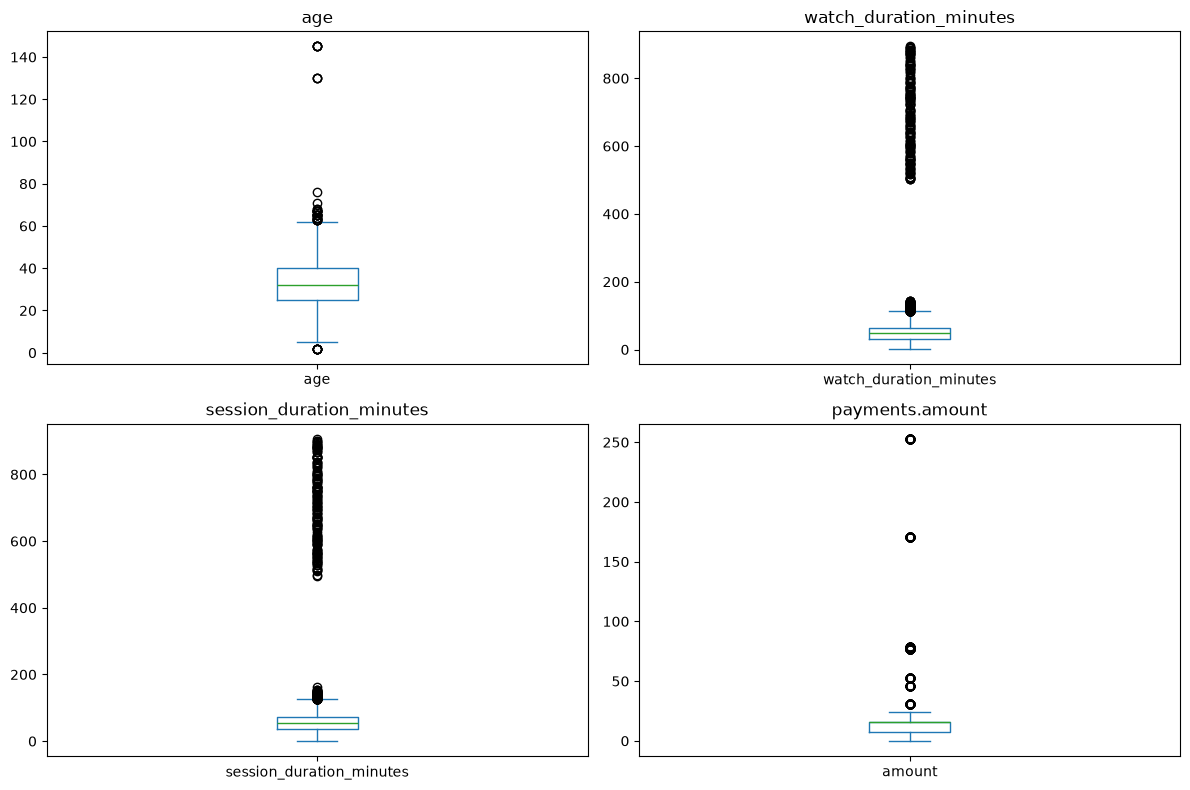

In [136]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df_customers["age"].plot(kind="box", ax=axes[0, 0], title="age")
df_viewing_activity["watch_duration_minutes"].plot(kind="box", ax=axes[0, 1], title="watch_duration_minutes")
df_viewing_activity["session_duration_minutes"].plot(kind="box", ax=axes[1, 0], title="session_duration_minutes")
df_payments["amount"].plot(kind="box", ax=axes[1, 1], title="payments.amount")

plt.tight_layout()
plt.show()

In [137]:
print("Age outliers (sample):")
display(df_customers.loc[age_out, ["customer_id", "age", "country"]].sort_values("age", ascending=False).head(15))
print("Age value counts among IQR outliers:")
display(df_customers.loc[age_out, "age"].value_counts().sort_index())

print("\nWatch-duration outliers (largest):")
display(df_viewing_activity.loc[watch_out, ["viewing_id", "watch_duration_minutes", "session_duration_minutes"]].nlargest(8, "watch_duration_minutes"))

print("\nPayment amounts flagged by IQR:")
display(df_payments.loc[amount_out, "amount"].value_counts().sort_index())
print("These match 2x or 11x monthly plan prices (6.99 / 15.49 / 22.99), so they look like real double/annual charges.")

Age outliers (sample):


,customer_id,age,country
26,CUST004740,145.0,United States
6384,CUST003431,145.0,United States
3149,CUST003419,145.0,United Kingdom
6935,CUST007533,145.0,India
5904,CUST003225,145.0,Canada
6682,CUST002713,130.0,South Korea
5085,CUST001369,130.0,Argentina
2395,CUST000463,130.0,Argentina
4628,CUST002396,76.0,India
196,CUST006392,71.0,United States


Age value counts among IQR outliers:


age
2.0      8
63.0     5
64.0     4
65.0     7
66.0     1
67.0     6
68.0     2
71.0     1
76.0     1
130.0    3
145.0    5
Name: count, dtype: int64


Watch-duration outliers (largest):


,viewing_id,watch_duration_minutes,session_duration_minutes
42156,VIEW00042157,894,897
50965,VIEW00050966,893,907
47676,VIEW00047677,890,899
61658,VIEW00061659,889,890
22219,VIEW00022220,888,899
8648,VIEW00008649,883,893
36029,VIEW00036030,883,887
11198,VIEW00011199,881,883



Payment amounts flagged by IQR:


amount
30.98      82
45.98      44
52.67      60
76.89     101
78.17      47
170.39     71
252.89     58
Name: count, dtype: int64

These match 2x or 11x monthly plan prices (6.99 / 15.49 / 22.99), so they look like real double/annual charges.


In [138]:
age_too_young = (df_customers["age"] < 13).sum()
age_impossible = (df_customers["age"] > 100).sum()
df_customers["age"] = df_customers["age"].clip(lower=13, upper=100)

watch_capped = watch_out.sum()
session_capped = session_out.sum()
df_viewing_activity["watch_duration_minutes"] = df_viewing_activity["watch_duration_minutes"].clip(upper=watch_upper)
df_viewing_activity["session_duration_minutes"] = df_viewing_activity["session_duration_minutes"].clip(upper=session_upper)

print(f"age: capped {age_too_young} values < 13 up to 13, and {age_impossible} values > 100 down to 100")
print(f"watch_duration_minutes: winsorized {watch_capped} values at IQR upper bound {watch_upper:.1f}")
print(f"session_duration_minutes: winsorized {session_capped} values at IQR upper bound {session_upper:.1f}")
print(f"payments.amount: kept all {amount_out.sum()} IQR-flagged rows (no cap)")

age: capped 13 values < 13 up to 13, and 8 values > 100 down to 100
watch_duration_minutes: winsorized 443 values at IQR upper bound 113.5
session_duration_minutes: winsorized 357 values at IQR upper bound 125.5
payments.amount: kept all 463 IQR-flagged rows (no cap)


**Outlier decisions**

- **age:** IQR flagged 43 rows (below 2.5 or above 62.5). Ages 63–76 look like real older subscribers, so they were kept. Ages 2 and 5 are too young for an account holder (capped at 13). Ages 130 and 145 are impossible (capped at 100). No rows deleted.
- **watch_duration_minutes:** IQR flagged 443 rows above ~113.5 minutes. Long sessions can be real binges, so rows were kept and values were **winsorized** at the IQR upper bound instead of deleted.
- **session_duration_minutes:** IQR flagged 357 rows above ~125.5 minutes. Same approach: keep the row, cap the value at the IQR upper bound.
- **payments.amount:** IQR flagged 463 amounts above ~28.24. Those values match 2× or 11× the Basic/Standard/Premium prices (`13.98`, `30.98`, `45.98`, `76.89`, `170.39`, `252.89`), so they look like double charges or ~annual billing, not errors. **Left unchanged.**

## Step 8: Reconcile `payments.subscription_id`

Every payment has a blank `subscription_id`. Match each payment to the subscription that was active on `payment_date`. If more than one window matches (plan-change day), keep the newer subscription. Log payments that fall after cancellation rather than dropping them.

In [139]:
print("Blank subscription_id rows:", df_payments["subscription_id"].isna().sum(), "of", len(df_payments))

df_payments["payment_date"] = pd.to_datetime(df_payments["payment_date"], errors="coerce")

subs_windows = df_subscriptions.copy()
subs_windows["start"] = pd.to_datetime(subs_windows["subscription_start_date"], errors="coerce")
subs_windows["effective_end"] = pd.to_datetime(
    subs_windows["subscription_end_date"], errors="coerce"
).fillna(pd.to_datetime(subs_windows["cancellation_date"], errors="coerce"))
subs_windows["end_fill"] = subs_windows["effective_end"].fillna(pd.Timestamp("2262-04-11"))

print("Effective end missing by status (open-ended = Active):")
display(subs_windows.groupby("subscription_status")["effective_end"].apply(lambda s: s.isna().sum()))

Blank subscription_id rows: 110735 of 110735
Effective end missing by status (open-ended = Active):


subscription_status
Active          6009
Cancelled          0
Plan Changed       0
Name: effective_end, dtype: int64

In [140]:
pay = df_payments.drop(columns=["subscription_id"])
merged = pay.merge(
    subs_windows[
        ["subscription_id", "customer_id", "start", "effective_end", "end_fill", "subscription_status"]
    ],
    on="customer_id",
    how="left",
)

in_window = (merged["payment_date"] >= merged["start"]) & (merged["payment_date"] <= merged["end_fill"])
matched = merged.loc[in_window].sort_values(["payment_id", "start"])
overlap_payments = matched.duplicated("payment_id", keep=False).sum() // 2
matched = matched.drop_duplicates("payment_id", keep="last")

unmatched = pay[~pay["payment_id"].isin(matched["payment_id"])].copy()
print("Unique in-window matches:", matched["payment_id"].nunique())
print("Plan-change overlap payments (kept the newer subscription):", overlap_payments)
print("Unmatched payments:", len(unmatched))

Unique in-window matches: 109690
Plan-change overlap payments (kept the newer subscription): 9
Unmatched payments: 1045


In [141]:
last_sub = (
    subs_windows.sort_values("start")
    .groupby("customer_id", as_index=False)
    .tail(1)[
        ["customer_id", "subscription_id", "effective_end", "subscription_status"]
    ]
    .rename(columns={
        "subscription_id": "fallback_subscription_id",
        "effective_end": "last_sub_end",
        "subscription_status": "last_sub_status",
    })
)

unmatched_log = unmatched.merge(last_sub, on="customer_id", how="left")
unmatched_log["days_after_end"] = (unmatched_log["payment_date"] - unmatched_log["last_sub_end"]).dt.days

print("Unmatched payment_status:")
display(unmatched_log["payment_status"].value_counts())
print("\nLast subscription status for unmatched payments:")
display(unmatched_log["last_sub_status"].value_counts())
print("\nDays after subscription ended:")
display(unmatched_log["days_after_end"].describe())
print("\nSample unmatched payments (billing continued after cancellation):")
display(
    unmatched_log[
        ["payment_id", "customer_id", "payment_date", "amount", "payment_status",
         "fallback_subscription_id", "last_sub_end", "last_sub_status", "days_after_end"]
    ].head(10)
)

Unmatched payment_status:


payment_status
Success    963
Failed      82
Name: count, dtype: int64


Last subscription status for unmatched payments:


last_sub_status
Cancelled    1045
Name: count, dtype: int64


Days after subscription ended:


count    1045.000000
mean       66.054545
std        50.759895
min         1.000000
25%        24.000000
50%        54.000000
75%        99.000000
max       231.000000
Name: days_after_end, dtype: float64


Sample unmatched payments (billing continued after cancellation):


,payment_id,customer_id,payment_date,amount,payment_status,fallback_subscription_id,last_sub_end,last_sub_status,days_after_end
0,PAY00000085,CUST000007,2026-05-28,15.49,Success,SUB0000007,2026-05-05,Cancelled,23
1,PAY00000180,CUST000014,2026-02-10,15.49,Success,SUB0000014,2026-01-31,Cancelled,10
2,PAY00000181,CUST000014,2026-03-12,15.49,Success,SUB0000014,2026-01-31,Cancelled,40
3,PAY00000182,CUST000014,2026-04-11,15.49,Success,SUB0000014,2026-01-31,Cancelled,70
4,PAY00000183,CUST000014,2026-05-11,15.49,Success,SUB0000014,2026-01-31,Cancelled,100
5,PAY00001100,CUST000082,2025-10-19,15.49,Success,SUB0000090,2025-10-16,Cancelled,3
6,PAY00001101,CUST000082,2025-11-18,15.49,Success,SUB0000090,2025-10-16,Cancelled,33
7,PAY00001102,CUST000082,2025-12-18,15.49,Success,SUB0000090,2025-10-16,Cancelled,63
8,PAY00001103,CUST000082,2026-01-17,15.49,Failed,SUB0000090,2025-10-16,Cancelled,93
9,PAY00001104,CUST000082,2026-02-16,15.49,Success,SUB0000090,2025-10-16,Cancelled,123


In [142]:
window_map = matched.set_index("payment_id")["subscription_id"]
fallback_map = unmatched_log.set_index("payment_id")["fallback_subscription_id"]

df_payments["subscription_id"] = df_payments["payment_id"].map(window_map)
still_blank = df_payments["subscription_id"].isna()
df_payments.loc[still_blank, "subscription_id"] = df_payments.loc[still_blank, "payment_id"].map(fallback_map)

print("subscription_id filled:", df_payments["subscription_id"].notna().sum())
print("still blank:", df_payments["subscription_id"].isna().sum())
print(
    "Match rate from active windows:",
    round(matched["payment_id"].nunique() / len(df_payments) * 100, 2), "%",
)
print("Filled from last cancelled subscription (logged above):", still_blank.sum())

subscription_id filled: 110735
still blank: 0
Match rate from active windows: 99.06 %
Filled from last cancelled subscription (logged above): 1045


**Matching result:** 109,690 / 110,735 payments matched an active subscription window (99.06%), including 9 plan-change days where both the old and new plan overlapped — those were assigned to the **newer** subscription.

**Unmatched (1,045):** every leftover payment is after a `Cancelled` subscription ended (median 51 days later, up to 231). These look like billing that continued after cancel, not missing customers. They were **logged** and then assigned that customer's last (cancelled) subscription so `subscription_id` is complete, rather than dropped.

## Step 9: Save the Cleaned Data

Write all nine cleaned tables to `data/processed/` and leave `data/raw/` untouched. Later notebooks and the database load should read from these files.

In [ ]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

cleaned_tables = {
    "customers": df_customers,
    "subscription_plans": df_subscription_plans,
    "subscriptions": df_subscriptions,
    "content": df_content,
    "viewing_activity": df_viewing_activity,
    "payments": df_payments,
    "support_tickets": df_support_tickets,
    "customer_feedback": df_customer_feedback,
    "churn_labels": df_churn_labels,
}

saved_rows = []
for name, df in cleaned_tables.items():
    path = PROCESSED_DIR / f"{name}_clean.csv"
    df.to_csv(path, index=False)
    saved_rows.append({"table": name, "rows": len(df), "columns": df.shape[1], "path": str(path)})

saved_summary = pd.DataFrame(saved_rows)
display(saved_summary)
print("Raw files left untouched in:", PROJECT_ROOT / "data" / "raw")

**Saved:** nine `*_clean.csv` files in `data/processed/` (`customers`, `subscription_plans`, `subscriptions`, `content`, `viewing_activity`, `payments`, `support_tickets`, `customer_feedback`, `churn_labels`). The originals in `data/raw/` were not modified.